In [1]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [2]:
df = pd.read_csv("D:/Codveda Technologies project/Umair-Level3-TASK1-Predictive Modeling/churn-bigml-80.csv")

df.head()


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   str    
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   str    
 4   Voice mail plan         2666 non-null   str    
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   float64
 15

In [4]:
df . shape

(2666, 20)

In [5]:
df.isnull().sum()

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [6]:
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [8]:
df[df.duplicated()].shape[0]

df[df.duplicated()].sum()

State                        
Account length              0
Area code                   0
International plan           
Voice mail plan              
Number vmail messages       0
Total day minutes         0.0
Total day calls             0
Total day charge          0.0
Total eve minutes         0.0
Total eve calls             0
Total eve charge          0.0
Total night minutes       0.0
Total night calls           0
Total night charge        0.0
Total intl minutes        0.0
Total intl calls            0
Total intl charge         0.0
Customer service calls      0
Churn                       0
dtype: object

In [9]:
print(df["Churn"].value_counts())

print("\nPercentage distribution:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
False    2278
True      388
Name: count, dtype: int64

Percentage distribution:
Churn
False    85.446362
True     14.553638
Name: proportion, dtype: float64


In [11]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2666, 19)
Target shape: (2666,)


In [13]:
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("/nNumerical columns:")
print(numerical_columns)

Categorical columns:
['State', 'International plan', 'Voice mail plan']
/nNumerical columns:
['Account length', 'Area code', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']


C:\Users\umair\AppData\Local\Temp\ipykernel_8264\1944623582.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()


In [15]:
# 1. Preprocess the data

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_columns
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ]
)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2132, 19)
Testing data: (534, 19)


In [19]:
# 2. Train and test multiple classification models eg: Decision Trees, Logistic Regression, Random Forests, etc.

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

decision_tree_pipeline.fit(X_train, y_train)

dt_predictions = decision_tree_pipeline.predict(X_test)

logistic_regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(random_state=500, max_iter=1000))
    ]
)

logistic_regression_pipeline.fit(X_train, y_train)

lr_predictions = logistic_regression_pipeline.predict(X_test)

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=600, n_estimators=100))
    ]
)

random_forest_pipeline.fit(X_train, y_train)

rf_predictions = random_forest_pipeline.predict(X_test)


In [20]:
# 3. Evaluate the model using accuracy, precision, recall, and F1-score.

dt_accuracy = accuracy_score(y_test, dt_predictions)
dt_precision = precision_score(y_test, dt_predictions)
dt_recall = recall_score(y_test, dt_predictions)
dt_f1 = f1_score(y_test, dt_predictions)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1-score :", dt_f1)

lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions)
lr_recall = recall_score(y_test, lr_predictions)
lr_f1 = f1_score(y_test, lr_predictions)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1-score :", lr_f1)

rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-score :", rf_f1)



Decision Tree Results
---------------------
Accuracy : 0.9063670411985019
Precision: 0.6794871794871795
Recall   : 0.6794871794871795
F1-score : 0.6794871794871795
Logistic Regression Results
---------------------------
Accuracy : 0.8426966292134831
Precision: 0.425
Recall   : 0.21794871794871795
F1-score : 0.288135593220339
Random Forest Results
---------------------
Accuracy : 0.9382022471910112
Precision: 1.0
Recall   : 0.5769230769230769
F1-score : 0.7317073170731707


In [22]:
results = {
    "Model": ["Decision Tree", "Logistic Regression", "Random Forest"],
    "Accuracy": [dt_accuracy, lr_accuracy, rf_accuracy],
    "Precision": [dt_precision, lr_precision, rf_precision],
    "Recall": [dt_recall, lr_recall, rf_recall],
    "F1-Score": [dt_f1, lr_f1, rf_f1]
}
print(results)

{'Model': ['Decision Tree', 'Logistic Regression', 'Random Forest'], 'Accuracy': [0.9063670411985019, 0.8426966292134831, 0.9382022471910112], 'Precision': [0.6794871794871795, 0.425, 1.0], 'Recall': [0.6794871794871795, 0.21794871794871795, 0.5769230769230769], 'F1-Score': [0.6794871794871795, 0.288135593220339, 0.7317073170731707]}


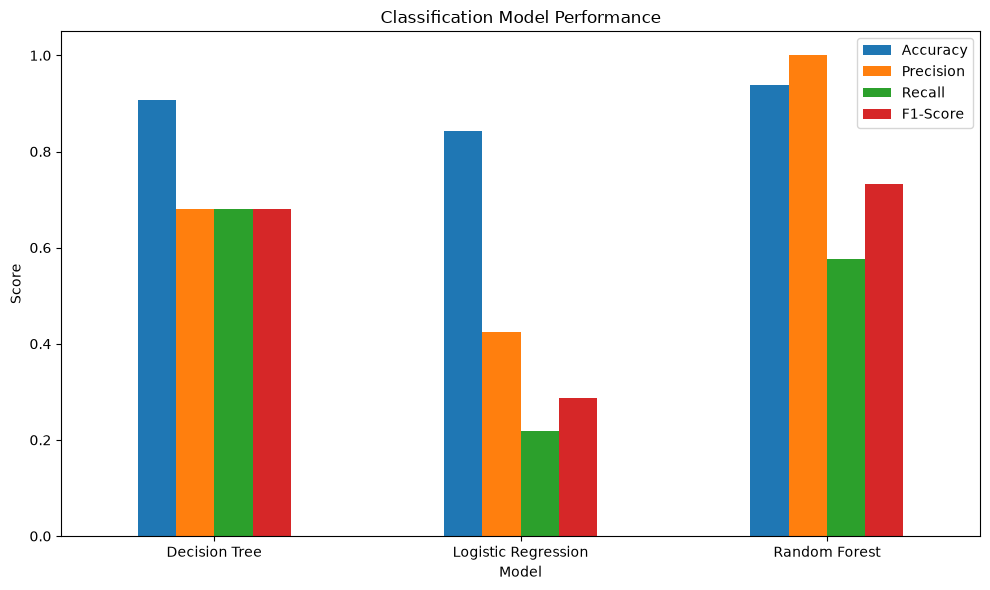

In [26]:
results = pd.DataFrame(results)

results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
].plot(kind="bar", figsize=(10, 6))

plt.title("Classification Model Performance")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
# 4. hyperparameter tuning using grid search

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(random_state=42)
        )
    ]
)

rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)



,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable a

In [ ]:
# conclusion:

# Several classification methods were used in this study to examine the customer turnover dataset: Random Forest, Decision Tree, and Logistic Regression.
# Feature scaling was applied to numerical variables, categorical variables were one-hot encoded, and numerical and categorical variables were separated as part of the preprocessing of the data.
# Accuracy, precision, recall, and F1-score were used to assess the three classification models. The Random Forest hyperparameters were then adjusted using GridSearchCV to see whether model performance could be enhanced.
# The actual test-set performance derived from the analysis served as the basis for the final model comparison. The findings shed light on the application of machine-learning categorisation in customer churn prediction.